<a href="https://colab.research.google.com/github/Fadillah-Dama/PCVK_Ganjil_26/blob/main/Week1_Tugas_Praktikum_D3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

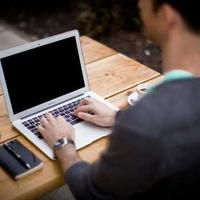

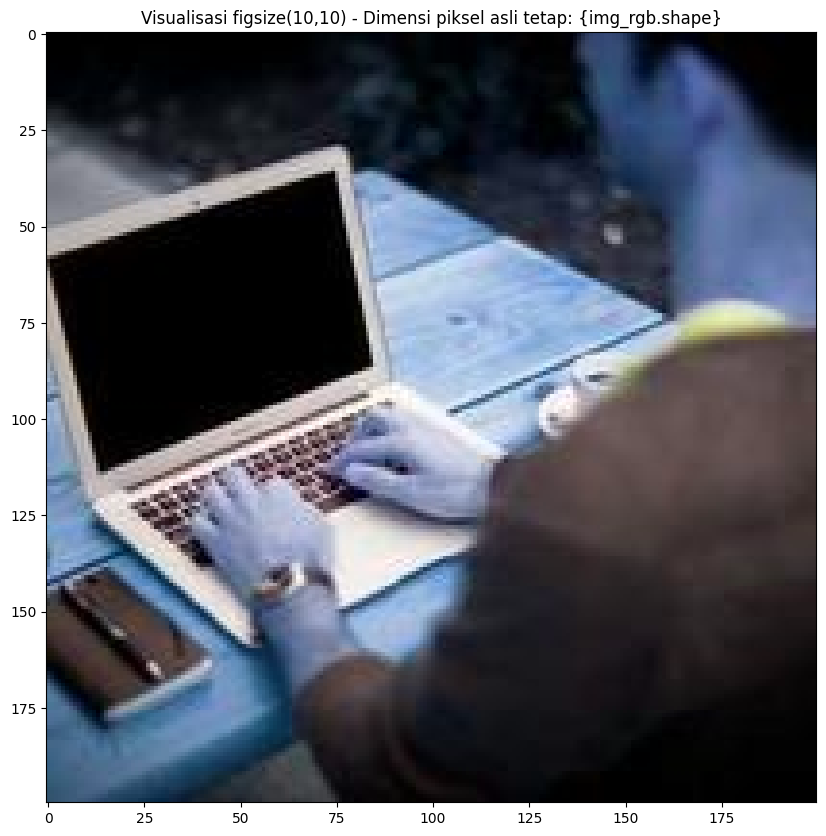

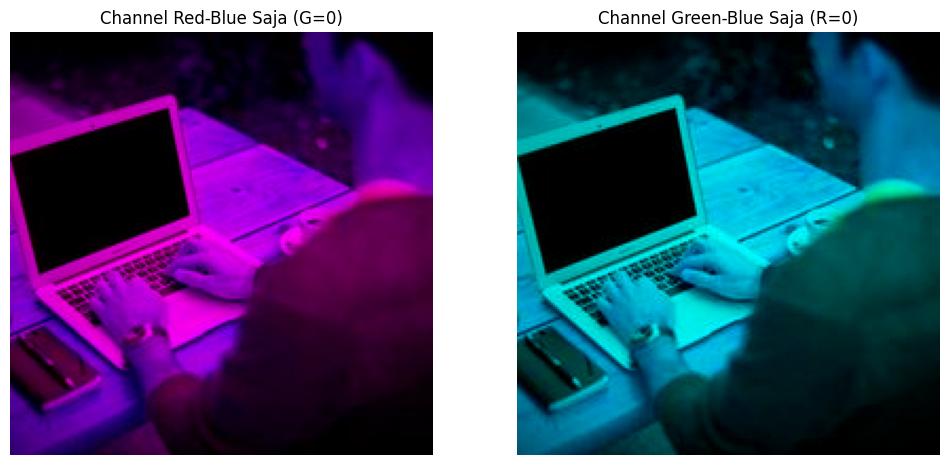

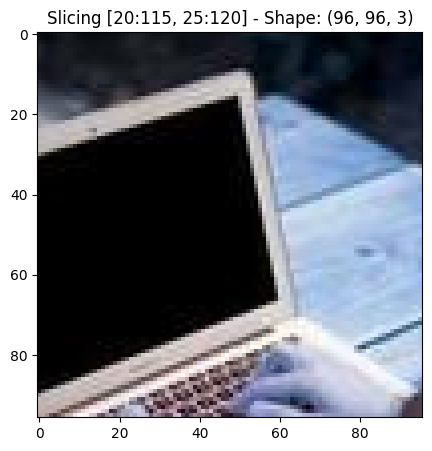

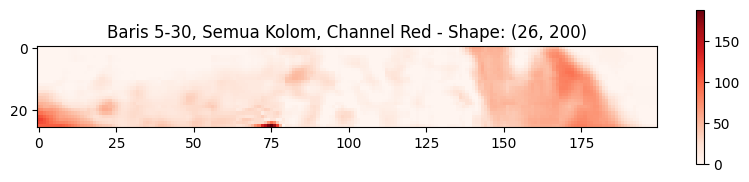

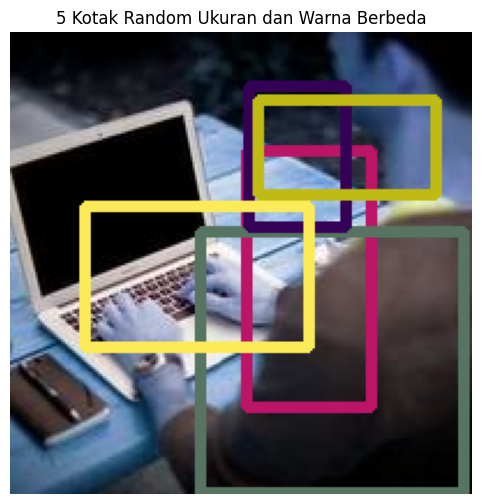

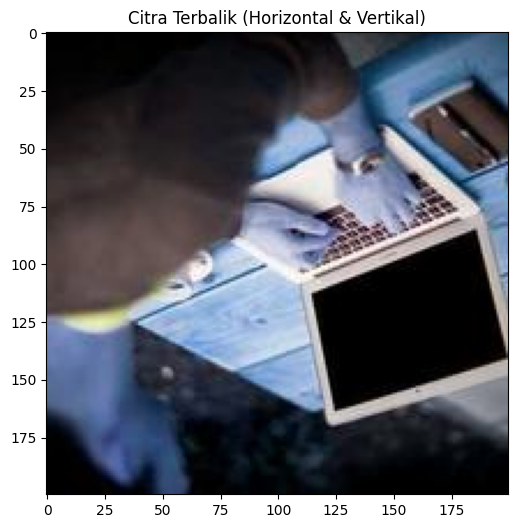

Saving aktivitas.jpeg to aktivitas (8).jpeg


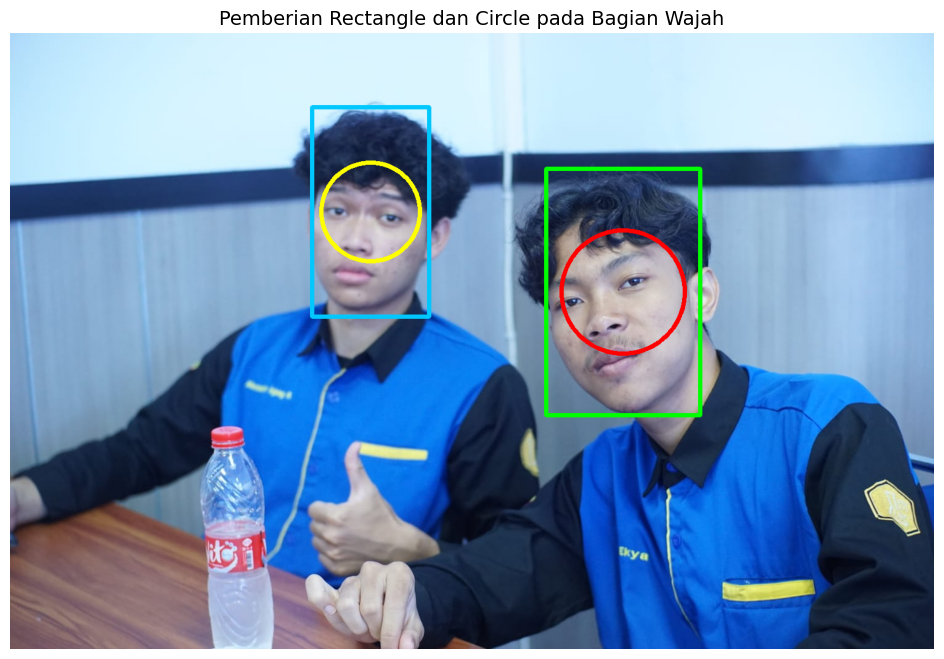

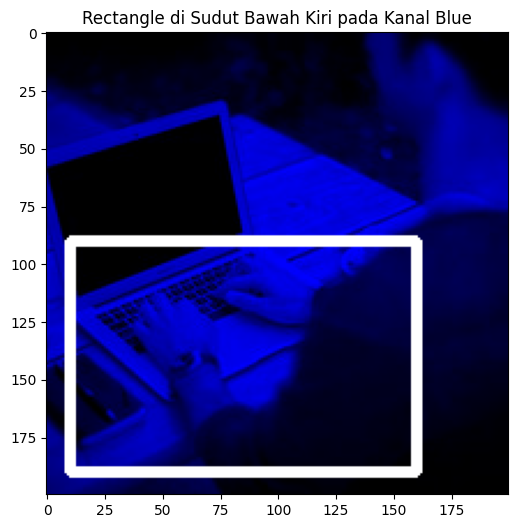

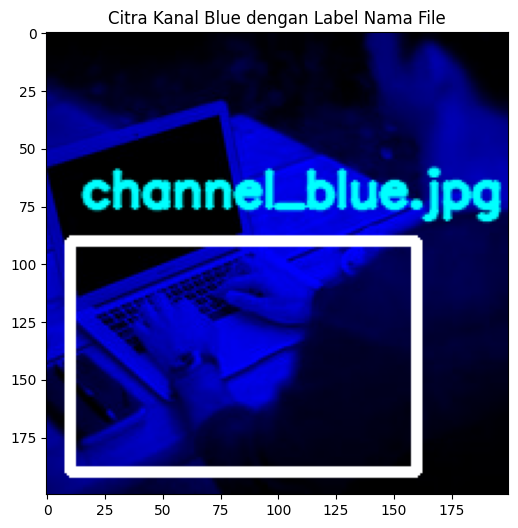

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from skimage import io
from google.colab import files


IMAGE_PATH = "https://picsum.photos/id/1/200"

# Membaca citra & mengonversi ke RGB untuk plotting matplotlib
img_raw = io.imread(IMAGE_PATH)
img_rgb = cv.cvtColor(img_raw, cv.COLOR_BGR2RGB)

cv2_imshow(img_rgb)

# 1. Pengaruh figsize terhadap Ukuran Piksel Citra
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(img_rgb)
ax.set_title("Visualisasi figsize(10,10) - Dimensi piksel asli tetap: {img_rgb.shape}")
plt.show()

# 2.
# Channel Red-Blue (Menghilangkan Green -> index 1)
img_rb = img_rgb.copy()
img_rb[:, :, 1] = 0

# Channel Green-Blue (Menghilangkan Red -> index 0)
img_gb = img_rgb.copy()
img_gb[:, :, 0] = 0

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_rb)
axes[0].set_title("Channel Red-Blue Saja (G=0)")
axes[0].axis('off')

axes[1].imshow(img_gb)
axes[1].set_title("Channel Green-Blue Saja (R=0)")
axes[1].axis('off')
plt.show()

# 3. Tampilkan Image Baris 20–115, Kolom 25–120 (Slicing/Cropping)
cropped_area = img_rgb[20:116, 25:121]

plt.figure(figsize=(5, 5))
plt.imshow(cropped_area)
plt.title(f"Slicing [20:115, 25:120] - Shape: {cropped_area.shape}")
plt.show()

# 4. Ambil baris 5 s.d 30, semua kolom, kanal 0 (Red)
red_strip = img_rgb[5:31, :, 0]

plt.figure(figsize=(10, 2))
plt.imshow(red_strip, cmap="Reds")
plt.title(f"Baris 5-30, Semua Kolom, Channel Red - Shape: {red_strip.shape}")
plt.colorbar()
plt.show()

# 5. Buat 5 Kotak Berbagai Ukuran & Warna Berbeda (Acak / Random)
img_boxes = img_rgb.copy()
h, w, _ = img_boxes.shape

np.random.seed(42) # Seed agar hasil reproduksibel

for i in range(5):
    # Koordinat acak
    x1, y1 = np.random.randint(0, w - 80), np.random.randint(0, h - 80)
    box_w, box_h = np.random.randint(40, 120), np.random.randint(40, 120)
    x2, y2 = min(x1 + box_w, w - 1), min(y1 + box_h, h - 1)

    # Warna acak (R, G, B)
    color = [int(c) for c in np.random.randint(0, 256, size=3)]

    # Gambar persegi (thickness=-1 untuk kotak solid / terisi penuh)
    cv.rectangle(img_boxes, (x1, y1), (x2, y2), color, thickness=3)

plt.figure(figsize=(8, 6))
plt.imshow(img_boxes)
plt.title("5 Kotak Random Ukuran dan Warna Berbeda")
plt.axis('off')
plt.show()

# 6. Tampilkan gambar dengan terbalik
img_flipped = cv.flip(img_rgb, -1) # Terbalik vertikal & horizontal

plt.figure(figsize=(8, 6))
plt.imshow(img_flipped)
plt.title("Citra Terbalik (Horizontal & Vertikal)")
plt.show()

# 7. Buat rectangle dan circle pada foto wajah

# Upload file gambar
uploaded = files.upload()

# Ambil nama file yang baru saja diupload
filename = list(uploaded.keys())[0]

# Baca gambar menggunakan OpenCV (menghasilkan numpy array)
foto = cv.imread(filename)

# Konversi format BGR OpenCV ke RGB agar warna di Matplotlib tampil tepat
foto_rgb = cv.cvtColor(foto, cv.COLOR_BGR2RGB)

# Salin gambar agar gambar asli tidak tertimpa
foto_marked = foto_rgb.copy()

# Orang Kanan (Depan):
# Rectangle Hijau membingkai area wajah
cv.rectangle(foto_marked, pt1=(870, 220), pt2=(1120, 620), color=(0, 255, 0), thickness=6)
# Circle Merah di area tengah wajah
cv.circle(foto_marked, center=(995, 420), radius=100, color=(255, 0, 0), thickness=5)

# Orang Kiri (Belakang):
# Rectangle Biru Terang membingkai area wajah
cv.rectangle(foto_marked, pt1=(490, 120), pt2=(680, 460), color=(0, 200, 255), thickness=6)
# Circle Kuning di area tengah wajah
cv.circle(foto_marked, center=(585, 290), radius=80, color=(255, 255, 0), thickness=5)

# Tampilkan hasil visualisasi
plt.figure(figsize=(12, 8))
plt.imshow(foto_marked)
plt.title("Pemberian Rectangle dan Circle pada Bagian Wajah", fontsize=14)
plt.axis("off")
plt.show()

# 8. Buat rectangle pada bagian sudut bawah kiri channel B pada color space RGB dari citra
# Ambil kanal Blue murni dalam format RGB 3-channel
h, w, _ = img_rgb.shape
blue_channel_img = np.zeros_like(img_rgb)
blue_channel_img[:, :, 2] = img_rgb[:, :, 2]  # Salin kanal Blue (indeks 2)

# Buat rectangle di pojok kiri bawah: x: 0 s.d 150, y: (h-150) s.d h
cv.rectangle(blue_channel_img, pt1=(10, h - 110), pt2=(160, h - 10), color=(255, 255, 255), thickness=3)

plt.figure(figsize=(8, 6))
plt.imshow(blue_channel_img)
plt.title("Rectangle di Sudut Bawah Kiri pada Kanal Blue")
plt.show()

# 9. lengkapi citra nomor 8
img_text = blue_channel_img.copy()

file_name_text = "channel_blue.jpg"

# Tambahkan teks di dekat sudut kiri bawah / di atas rectangle
font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(
    img_text,
    text=file_name_text,
    org=(15, h - 125),
    fontFace=font,
    fontScale=0.7,
    color=(0, 255, 255),
    thickness=2,
    lineType=cv.LINE_AA
)

plt.figure(figsize=(8, 6))
plt.imshow(img_text)
plt.title("Citra Kanal Blue dengan Label Nama File")
plt.show()